In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error , mean_absolute_percentage_error

### Linear_regression Model

In [96]:
df = pd.read_csv('ToyotaCorolla - MLR.csv') # Loding the data set 

In [97]:
df.head() # print top 5 rows from the data set

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


### Column Discription

### EDA 

In [98]:
print(f'Total rows and columns repectively = {df.shape}') # print the total rows and columns in the data set

Total rows and columns repectively = (1436, 11)


In [99]:
print(f'Total elements inside the dataset = {df.size}') # print the total elements inside the data set

Total elements inside the dataset = 15796


In [100]:
df.info() # give a info summary of the data set like how the data set is looking 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
# checking null value inside data 
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [8]:
# checking duplicates
df.duplicated().sum()

np.int64(1)

In [9]:
# droping duplicates
df.drop_duplicates(ignore_index=True,inplace=True)

### Spliting Feature and Target

In [10]:
target = df[['Price']]
features = df.drop(columns=['Price'])

In [11]:
target.head()

,Price
0,13500
1,13750
2,13950
3,14950
4,13750


In [12]:
features.head()

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23,46986,Diesel,90,0,2000,3,4,5,1165
1,23,72937,Diesel,90,0,2000,3,4,5,1165
2,24,41711,Diesel,90,0,2000,3,4,5,1165
3,26,48000,Diesel,90,0,2000,3,4,5,1165
4,30,38500,Diesel,90,0,2000,3,4,5,1170


<Axes: >

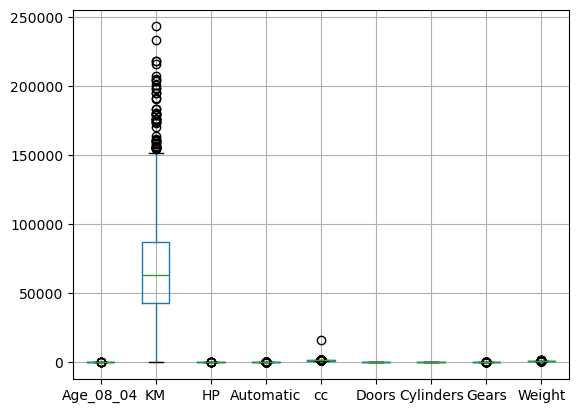

In [13]:
# checking ouliers 
features.boxplot()

In [14]:
# Outlier capping
def outlier_capping(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_extreme = q1 - 1.5*iqr
    upper_extreme = q3 + 1.5*iqr
    df[column] = df[column].apply(
        lambda x : lower_extreme if x < lower_extreme else upper_extreme if x > upper_extreme else x
    )
for col in features.select_dtypes(include=['int','float']).columns:
    outlier_capping(features,col)

In [101]:
# above wirtten code will find the q1,q3 and iqr for the each column then if the column contains the outlier then this code also replace these 
# outliers with there respective value

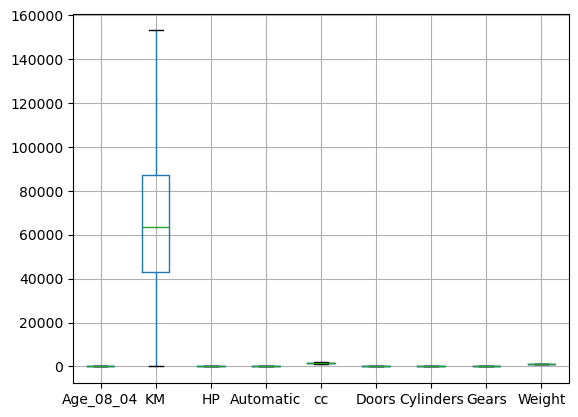

In [15]:
features.boxplot()
plt.show()

In [102]:
# feature selection
from sklearn.feature_selection import f_regression # this package is used for the feature selection

In [17]:
# There is one column with name Fuel_Type due to this we cannot use feature selection because this column is in the object dtype also we are not doing 
# labeling before the train_test_split because, if we do then it will create data leakage problem.
# so we are doing the train_test_split then we will do the feature selection after this

### Train Test split 

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train,x_test,y_train,y_test  = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 10)
(287, 10)
(1148, 1)
(287, 1)


### Data Preprocesing

#### Labeling

In [20]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder

In [21]:
one_hot = OneHotEncoder()

In [22]:
one_hot= OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_train_enc=pd.DataFrame(data=one_hot.fit_transform(x_train[['Fuel_Type']]),columns=one_hot.get_feature_names_out(),index=x_train.index)
x_test_enc= pd.DataFrame(data=one_hot.transform(x_test[['Fuel_Type']]),columns=one_hot.get_feature_names_out(),index=x_test.index) 

In [23]:
x_train_enc.shape, x_test_enc.shape

((1148, 3), (287, 3))

In [24]:
# Droping the categorical column from the data 
x_train.drop(columns=['Fuel_Type'],inplace=True)
x_test.drop(columns=['Fuel_Type'],inplace=True)

In [25]:
x_train_final= pd.concat([x_train,x_train_enc],axis=1)
x_train_final.shape

(1148, 12)

In [26]:
x_test_final= pd.concat([x_test,x_test_enc],axis=1)
x_test_final.shape

(287, 12)

#### Scaling 

In [27]:
std_scale = StandardScaler()

In [28]:
x_train_final.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
108,20.0,7187.0,110.0,0.0,1600.0,3,4,5.0,1105.0,0.0,0.0,1.0
1279,78.0,73638.0,86.0,0.0,1300.0,4,4,5.0,1015.0,0.0,0.0,1.0
857,62.0,64797.0,110.0,0.0,1600.0,5,4,5.0,1075.0,0.0,0.0,1.0
902,65.0,59000.0,110.0,0.0,1600.0,5,4,5.0,1075.0,0.0,0.0,1.0
372,33.0,16512.0,97.0,0.0,1400.0,5,4,5.0,1085.0,0.0,0.0,1.0


In [29]:
for col in x_train_final.columns:
    print('--'*50)
    print(f'{col} :-',x_train_final[col].nunique())

----------------------------------------------------------------------------------------------------
Age_08_04 :- 74
----------------------------------------------------------------------------------------------------
KM :- 982
----------------------------------------------------------------------------------------------------
HP :- 12
----------------------------------------------------------------------------------------------------
Automatic :- 1
----------------------------------------------------------------------------------------------------
cc :- 9
----------------------------------------------------------------------------------------------------
Doors :- 4
----------------------------------------------------------------------------------------------------
Cylinders :- 1
----------------------------------------------------------------------------------------------------
Gears :- 1
-------------------------------------------------------------------------------------------------

In [30]:
x_train_final[['Age_08_04','KM','HP','cc','Doors','Weight']] = std_scale.fit_transform(x_train_final[['Age_08_04','KM','HP','cc','Doors','Weight']])
x_test_final[['Age_08_04','KM','HP','cc','Doors','Weight']] = std_scale.transform(x_test_final[['Age_08_04','KM','HP','cc','Doors','Weight']])

In [31]:
# Scaling and labeling are done 
x_train_final.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
108,-1.940533,-1.748188,0.689004,0.0,0.255237,-1.074130,4,5.0,0.954608,0.0,0.0,1.0
1279,1.182405,0.176456,-1.123604,0.0,-1.492799,-0.024682,4,5.0,-1.387370,0.0,0.0,1.0
857,0.320905,-0.079609,0.689004,0.0,0.255237,1.024766,4,5.0,0.173948,0.0,0.0,1.0
902,0.482436,-0.247509,0.689004,0.0,0.255237,1.024766,4,5.0,0.173948,0.0,0.0,1.0
372,-1.240564,-1.478104,-0.292825,0.0,-0.910121,1.024766,4,5.0,0.434168,0.0,0.0,1.0


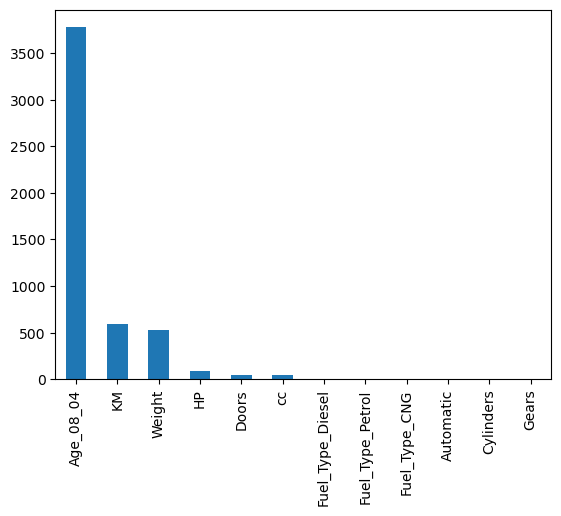

In [32]:
# Doing feature selection
f_reg = f_regression(x_train_final,y_train)[0]
pd.Series(f_reg,index=x_train_final.columns).sort_values(ascending = False).plot(kind = 'bar')
plt.show()

In [33]:
# checking multicolinearity 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [34]:
vif = pd.DataFrame()
vif['features'] = x_train_final.columns
vif['vif_score'] = [
    variance_inflation_factor(x_train_final.values,i)for i in range(len(x_train_final.columns))
]
vif

,features,vif_score
0,Age_08_04,2.284896
1,KM,2.053249
2,HP,9.822029
3,Automatic,NaN
4,cc,12.808479
5,Doors,1.310789
6,Cylinders,0.000000
7,Gears,0.000000
8,Weight,4.003285
9,Fuel_Type_CNG,inf


In [35]:
# droping some multicolinearity columns
x_train_final.drop(columns=['cc','Fuel_Type_CNG'],inplace = True)
x_test_final.drop(columns=['cc','Fuel_Type_CNG'],inplace = True)

In [36]:
# recalculating vif
vif = pd.DataFrame()
vif['features'] = x_train_final.columns
vif['vif_score'] = [
    variance_inflation_factor(x_train_final.values,i)for i in range(len(x_train_final.columns))
]
vif

,features,vif_score
0,Age_08_04,2.193598
1,KM,1.990704
2,HP,2.368417
3,Automatic,NaN
4,Doors,1.310422
5,Cylinders,0.000000
6,Gears,0.000000
7,Weight,3.793731
8,Fuel_Type_Diesel,10.961949
9,Fuel_Type_Petrol,9.461136


### Model1 

In [37]:
# we are taking above columns for the training and testing
from sklearn.linear_model import LinearRegression

In [38]:
lin_reg = LinearRegression()

In [39]:
lin_reg.fit(x_train_final,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Intercept and coefficient (Model 1)

In [79]:
lin_reg.intercept_

array([9604.7593108])

In [41]:
lin_reg.coef_

array([[-2.28115694e+03, -7.39443899e+02,  3.49549728e+02,
        -2.78532752e-12, -1.01899264e+02,  2.27373675e-13,
         0.00000000e+00,  1.00668282e+03,  7.73552462e+02,
         1.17947201e+03]])

In [42]:
# now finding the accuracy of the model with the help of r2 score 
from sklearn.metrics import r2_score

#### Training Accuracy 

In [43]:
y_pred = lin_reg.predict(x_train_final)
print(f'Accuracy from the model :- {r2_score(y_train,y_pred):.2f}')

Accuracy from the model :- 0.84


#### Testing Accuracy 

In [44]:
y_pred1 = lin_reg.predict(x_test_final)
print(f'Accuracy from the model :- {r2_score(y_test,y_pred1):.2f}')

Accuracy from the model :- 0.83


### Model 2 

In [45]:
# Elastic net
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

In [46]:
params = {
    'alpha': [0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.4, 0.5, 0.6, 0.9],
    'max_iter': [1000, 2000, 5000]
}

In [47]:
grid_search = GridSearchCV(
    estimator=ElasticNet(),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid_search.fit(x_train_final, y_train)

,estimator,ElasticNet()
,param_grid,"{'alpha': [0.1, 1, ...], 'l1_ratio': [0.1, 0.4, ...], 'max_iter': [1000, 2000, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [48]:
grid_search.best_params_,grid_search.best_score_

({'alpha': 0.1, 'l1_ratio': 0.9, 'max_iter': 1000},
 np.float64(0.8344458948262219))

In [49]:
# Training the model with best parameters 
elastic_net = ElasticNet(alpha=0.1,l1_ratio=0.9,max_iter=1000)
elastic_net.fit(x_test_final,y_test)
elastic_predict = elastic_net.predict(x_test_final)
r2_score(y_test,elastic_predict)

0.8299898505888841

#### Intercept and coefficient (Model 2)

In [80]:
elastic_net.coef_

array([-2393.93434473,  -695.83441683,   401.78898353,     0.        ,
         -54.25963082,     0.        ,     0.        ,   655.05542702,
         780.20446135,   597.61148629])

In [81]:
elastic_net.intercept_

array([10023.67439845])

### Model 3

In [53]:
mod_3_fet = features[['Age_08_04','KM','Weight','HP','Doors','cc']] #columns have high f_score value
mod_3_fet.head()

,Age_08_04,KM,Weight,HP,Doors,cc
0,23.0,46986.0,1152.5,90.0,3,1900.0
1,23.0,72937.0,1152.5,90.0,3,1900.0
2,24.0,41711.0,1152.5,90.0,3,1900.0
3,26.0,48000.0,1152.5,90.0,3,1900.0
4,30.0,38500.0,1152.5,90.0,3,1900.0


In [54]:
target.head()

,Price
0,13500
1,13750
2,13950
3,14950
4,13750


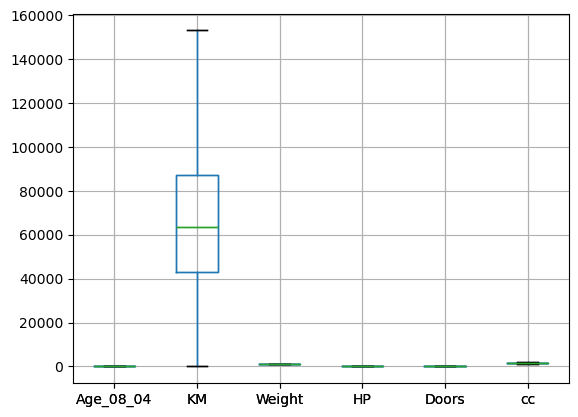

In [56]:
# checking outliers
mod_3_fet.boxplot()
plt.show()

In [63]:
# Train/Test Split 
x_train1,x_test1,y_train1,y_test1 = train_test_split(mod_3_fet,target,train_size=0.8,random_state=100)
print(x_train1.shape)
print(x_test1.shape)
print(y_train1.shape)
print(y_test1.shape)

(1148, 6)
(287, 6)
(1148, 1)
(287, 1)


In [64]:
x_test1.columns

Index(['Age_08_04', 'KM', 'Weight', 'HP', 'Doors', 'cc'], dtype='object')

In [65]:
# doing scaling 
from sklearn.preprocessing import StandardScaler

In [66]:
std_scale2 = StandardScaler()

In [67]:
mod_3_fet.head()

,Age_08_04,KM,Weight,HP,Doors,cc
0,23.0,46986.0,1152.5,90.0,3,1900.0
1,23.0,72937.0,1152.5,90.0,3,1900.0
2,24.0,41711.0,1152.5,90.0,3,1900.0
3,26.0,48000.0,1152.5,90.0,3,1900.0
4,30.0,38500.0,1152.5,90.0,3,1900.0


In [68]:
x_train1[['Age_08_04','KM','Weight','cc']] = std_scale2.fit_transform(x_train1[['Age_08_04','KM','Weight','cc']])
x_test1[['Age_08_04','KM','Weight','cc']] = std_scale2.transform(x_test1[['Age_08_04','KM','Weight','cc']])

In [69]:
x_train1.head()

,Age_08_04,KM,Weight,HP,Doors,cc
108,-1.940533,-1.748188,0.954608,110.0,3,0.255237
1279,1.182405,0.176456,-1.387370,86.0,4,-1.492799
857,0.320905,-0.079609,0.173948,110.0,5,0.255237
902,0.482436,-0.247509,0.173948,110.0,5,0.255237
372,-1.240564,-1.478104,0.434168,97.0,5,-0.910121


In [70]:
x_test1.head()

,Age_08_04,KM,Weight,HP,Doors,cc
57,-1.617470,-0.710923,1.084718,97.0,5,-0.910121
1002,0.320905,-0.826777,0.173948,110.0,5,0.255237
360,-1.132876,-1.260908,-1.127151,97.0,3,-0.910121
903,0.267061,-0.247509,0.043838,110.0,5,0.255237
1276,1.236249,0.189634,0.173948,110.0,5,0.255237


In [ ]:
from sklearn.linear_model import LinearRegression

In [71]:
lin_model1 = LinearRegression()

In [72]:
lin_model1.fit(x_train1,y_train1)
y_pred_1 = lin_model1.predict(x_train1)
train_acc = r2_score(y_train1,y_pred_1)
print(f'Accuracy during the training :- {train_acc}')

Accuracy during the training :- 0.8443661437491508


#### Intercept and coefficient (Model 3)

In [82]:
lin_model1.coef_

array([[-2222.98090743,  -674.79956825,  1296.66314954,    36.84768433,
         -165.32820545,  -455.4680011 ]])

In [83]:
lin_model1.intercept_

array([7673.75975751])

In [73]:
# Testing accuracy

In [74]:
y_pred_2 = lin_model1.predict(x_test1)
test_acc = r2_score(y_test1,y_pred_2)
print(f'Accuracy during the training :- {test_acc}')

Accuracy during the training :- 0.826375175348796


### Model conclusion

## Lasso & Ridge

### Lasso

In [75]:
from sklearn.linear_model import LassoCV

In [76]:
lasso_cv = LassoCV(n_alphas=100,max_iter=1000,cv=10)
lasso_cv.fit(x_train_final,y_train)

,eps,0.001
,n_alphas,100
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,10
,verbose,False
,n_jobs,None


In [78]:
# doing prediction from training
lass_predict = lasso_cv.predict(x_train_final)
lass_train_acc = r2_score(y_train,lass_predict)
print(f'Accuracy while training :- {lass_train_acc}')

Accuracy while training :- 0.8386914192720649


In [86]:
lasso_cv.alpha_ # this is the best alpha for the model 

np.float64(25.8945322502816)

#### Ridge 

In [87]:
from sklearn.linear_model import RidgeCV

In [91]:
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=10)
ridge_cv.fit(x_train_final, y_train)

,alphas,array([1.0000...00000000e+03])
,fit_intercept,True
,scoring,None
,cv,10
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [93]:
y_pred_train = ridge_cv.predict(x_train_final)
y_pred_test = ridge_cv.predict(x_test_final)
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

Train R2: 0.8402562488294062
Test R2: 0.8259176520353043


In [95]:
ridge_cv.alpha_ # the best alpha in the ridge_cv

np.float64(0.4641588833612782)

### Interview Question